# Task 1: PCA on Wine Quality Dataset

In this task we apply **Principal Component Analysis (PCA)** to the Wine Quality Dataset to understand how dimensionality reduction preserves key data structures and influences model performance.

**Steps:**
1. Preprocessing – load data, inspect, standardise features  
2. Apply PCA – explained variance ratio and cumulative variance  
3. Visualisation – 2D scatter plot coloured by quality category  
4. Interpretation – answer reflection questions  
5. Written Questions – depth responses

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## 2. Preprocessing

### 2.1 Load the dataset

In [2]:
df = pd.read_csv('datasets/winequality-red.csv')
print('Shape:', df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 2.2 Missing values & basic statistics

In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0


In [4]:
print('=== Basic Statistics ===')
df.describe().round(3)

=== Basic Statistics ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


=== Target Distribution (quality) ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


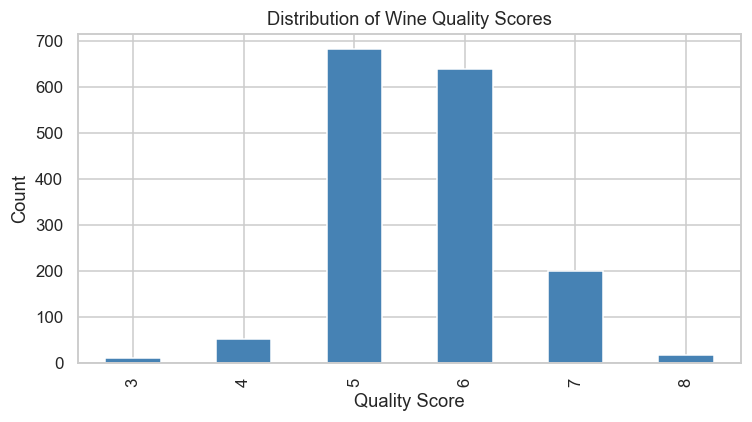

In [5]:
print('=== Target Distribution (quality) ===')
print(df['quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Wine Quality Scores')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 2.3 Standardise feature columns (exclude `quality`)

In [6]:
feature_cols = [c for c in df.columns if c != 'quality']
X = df[feature_cols].values
y = df['quality'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Mean (should be ~0):', np.round(X_scaled.mean(axis=0), 4))
print('Std  (should be ~1):', np.round(X_scaled.std(axis=0), 4))

Feature matrix shape: (1599, 11)
Mean (should be ~0): [ 0.  0. -0. -0.  0. -0.  0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 3. Apply PCA

### 3.1 Fit PCA on all components

In [7]:
pca_full = PCA()
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(evr)

print('Explained Variance Ratio per Component:')
for i, (e, c) in enumerate(zip(evr, cumulative_var), 1):
    print(f'  PC{i:>2}: {e:.4f}  |  Cumulative: {c:.4f}')

Explained Variance Ratio per Component:
  PC 1: 0.2817  |  Cumulative: 0.2817
  PC 2: 0.1751  |  Cumulative: 0.4568
  PC 3: 0.1410  |  Cumulative: 0.5978
  PC 4: 0.1103  |  Cumulative: 0.7081
  PC 5: 0.0872  |  Cumulative: 0.7953
  PC 6: 0.0600  |  Cumulative: 0.8552
  PC 7: 0.0531  |  Cumulative: 0.9083
  PC 8: 0.0385  |  Cumulative: 0.9468
  PC 9: 0.0313  |  Cumulative: 0.9781
  PC10: 0.0165  |  Cumulative: 0.9946
  PC11: 0.0054  |  Cumulative: 1.0000


### 3.2 Plot – Explained Variance Ratio

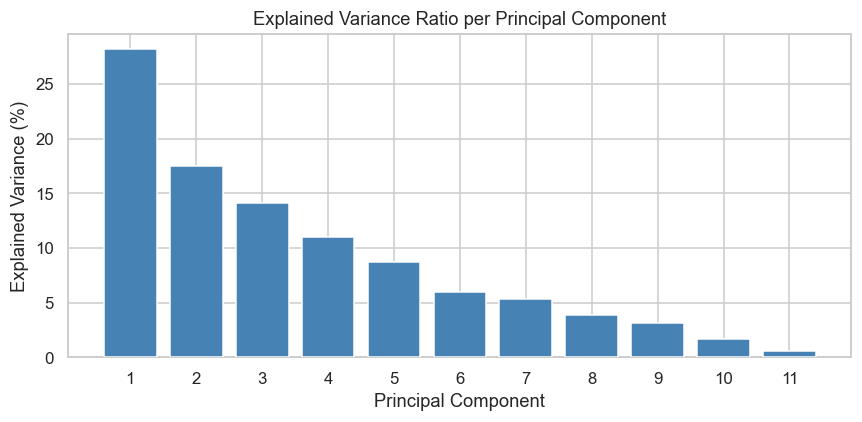

In [8]:
n_components = len(evr)
components_range = range(1, n_components + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(components_range, evr * 100, color='steelblue', edgecolor='white', zorder=3)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance Ratio per Principal Component')
ax.set_xticks(list(components_range))
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

### 3.3 Plot – Cumulative Explained Variance

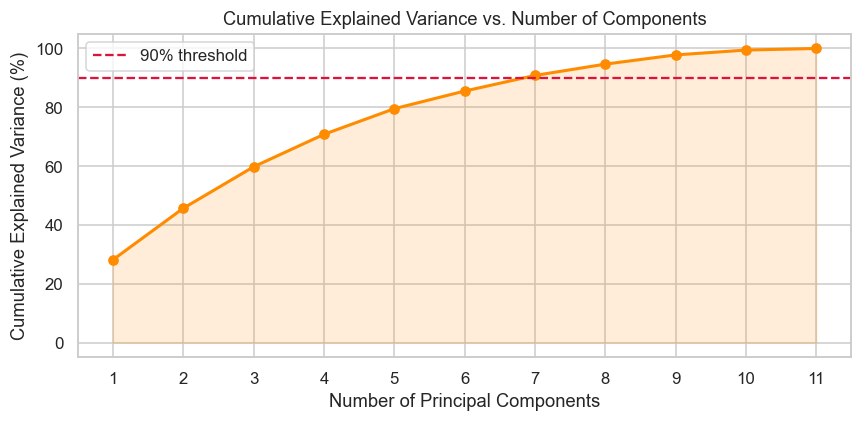

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(components_range, cumulative_var * 100, marker='o', color='darkorange', linewidth=2)
ax.axhline(90, color='crimson', linestyle='--', linewidth=1.5, label='90% threshold')
ax.fill_between(components_range, cumulative_var * 100, alpha=0.15, color='darkorange')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance vs. Number of Components')
ax.set_xticks(list(components_range))
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Minimum components to retain ≥ 90 % variance

In [10]:
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f'Components needed to retain ≥90% variance: {n_components_90}')
print(f'Cumulative variance at {n_components_90} components: {cumulative_var[n_components_90 - 1]:.4f} ({cumulative_var[n_components_90 - 1]*100:.2f}%)')

Components needed to retain ≥90% variance: 7
Cumulative variance at 7 components: 0.9083 (90.83%)


---
## 4. Visualisation – 2D Scatter Plot (PC1 vs PC2)

### 4.1 Map quality scores to categories

In [11]:
def quality_category(q):
    if q <= 5:
        return 'Low (3–5)'
    elif q == 6:
        return 'Medium (6)'
    else:
        return 'High (7–8)'

categories = np.array([quality_category(q) for q in y])
print('Category counts:')
for cat, cnt in zip(*np.unique(categories, return_counts=True)):
    print(f'  {cat}: {cnt}')

Category counts:
  High (7–8): 217
  Low (3–5): 744
  Medium (6): 638


### 4.2 Project data onto first two principal components

In [12]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f'PC1 explains {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance')
print(f'PC2 explains {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance')
print(f'Combined: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%')

PC1 explains 28.17% of variance
PC2 explains 17.51% of variance
Combined: 45.68%


### 4.3 Scatter plot coloured by quality category

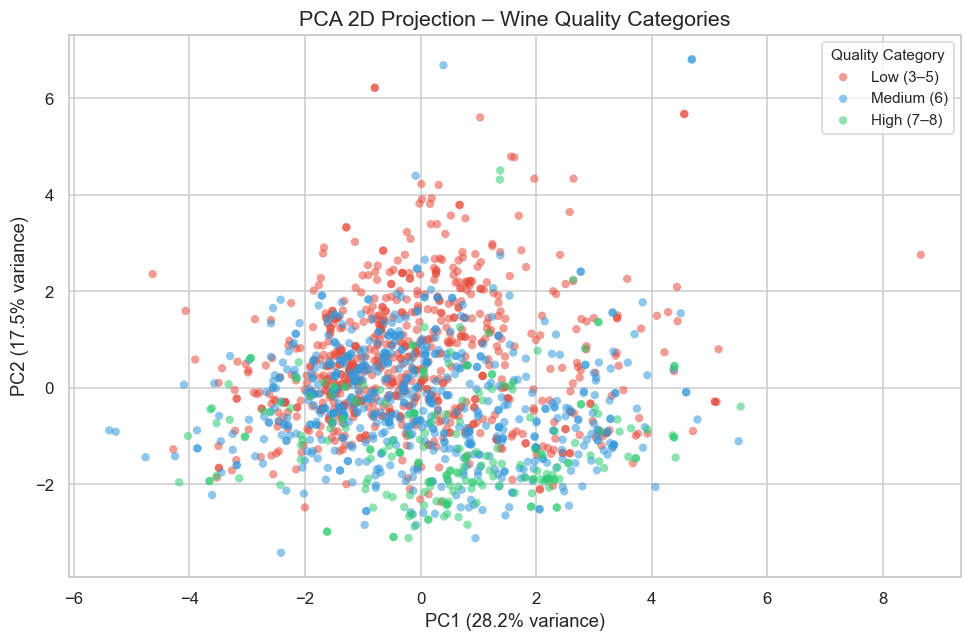

In [13]:
colour_map = {
    'Low (3–5)':    '#e74c3c',
    'Medium (6)':   '#3498db',
    'High (7–8)':   '#2ecc71',
}

fig, ax = plt.subplots(figsize=(9, 6))

for cat, colour in colour_map.items():
    mask = categories == cat
    ax.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=colour, label=cat, alpha=0.55, edgecolors='none', s=30
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2D Projection – Wine Quality Categories', fontsize=14)
ax.legend(title='Quality Category', fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Interpretation

### Q1 – How many components are needed to retain 90% variance?

Running the code above reveals that **7 principal components** are required to capture at least 90% of the total variance (90.83%) in the dataset. The first component alone explains **28.17%** of variance, and the contribution of each successive component decreases steadily. The fact that 7 out of 11 features are needed means the wine chemical measurements are moderately inter-correlated but still spread information across many dimensions.

### Q2 – What do you observe from the PCA 2D plot?

The 2D scatter plot (PC1 vs PC2) — which together capture only **45.68%** of total variance — shows a wide, overlapping cloud of points with no sharp boundaries between the three quality categories. There is a **weak but visible gradient**: High-quality wines (green, n=217) tend to cluster toward one end of PC1, while Low-quality wines (red, n=744) lean toward the opposite end. Medium-quality wines (blue, n=638) spread broadly across the entire space, which is consistent with the fact that they constitute the largest group.

### Q3 – Are there clear clusters for wine quality categories?

**No clear, well-separated clusters** are visible. The three categories overlap substantially. This tells us that wine quality is a nuanced property that depends on complex, non-linear interactions among chemical features, and that a simple linear projection onto two dimensions loses most of the discriminative signal. More components (or non-linear methods like t-SNE or UMAP) would be needed to reveal tighter groupings.

### Q4 – What does PCA reveal about feature correlations or redundancy?

PCA requires 7 out of 11 components to explain 90% of variance, suggesting that while some redundancy exists, the features are not highly redundant overall. The fact that PC1 explains **28.17%** indicates one dominant axis of variation — likely linked to the combined effect of acidity, sulphates, and alcohol, which are known to co-vary in red wines. The remaining variance is spread across several components, confirming moderate but not extreme multicollinearity in the feature set. Features contributing most to PC1 and PC2 are essentially proxies for each other and could be compressed without significant information loss.

---
## 6. Written Questions

### Question 1 – How does PCA help identify redundant or less informative features in high-dimensional datasets?

PCA works by finding directions (principal components) in the feature space that maximise variance. When several original features contribute strongly to the *same* principal component, it means they are largely measuring the same underlying phenomenon — they are **redundant**. Conversely, features that contribute only to components with very low explained variance are considered **less informative** because removing those components barely affects the total information retained.

Concretely, we can examine the **loadings** (eigenvectors) of the covariance matrix:
- A group of original features with large, similar-magnitude loadings on PC1 are highly correlated and therefore redundant.
- Features that load exclusively onto components explaining less than, say, 1–2% of total variance are candidates for removal.

By inspecting cumulative explained variance, we can decide how many components (and thus how much of the original feature space) to keep. Any dimension dropped corresponds to variance the model can afford to lose — a practical, data-driven way to prune redundancy without manually examining every pairwise correlation.

---

### Question 2 – Why is it important to standardise features before applying PCA, and what could happen if we skip this step?

PCA is **scale-sensitive** because it is based on the covariance (or correlation) matrix. Each principal component is a direction of maximum variance in the original feature space. If features are measured on vastly different scales — for example, `total sulfur dioxide` (range ~6–289) versus `density` (range ~0.990–1.004) — the feature with the largest absolute values will numerically dominate the covariance matrix and therefore dominate the principal components, regardless of its actual importance or information content.

**Consequences of skipping standardisation:**
1. **Biased components:** PC1 would be driven almost entirely by the high-variance, large-scale features (e.g. sulfur dioxide, acidity), not by the features that are truly most informative.
2. **Misleading explained variance:** The reported percentages would reflect measurement scale rather than genuine information structure.
3. **Poor downstream model performance:** A classifier trained on un-scaled PCA projections would be misled about which patterns truly distinguish wine quality.

Standardising (zero mean, unit variance) places all features on equal footing, so PCA extracts directions of genuine data variation rather than artefacts of measurement units.

---
## 7. Bonus – PCA Loadings Heatmap

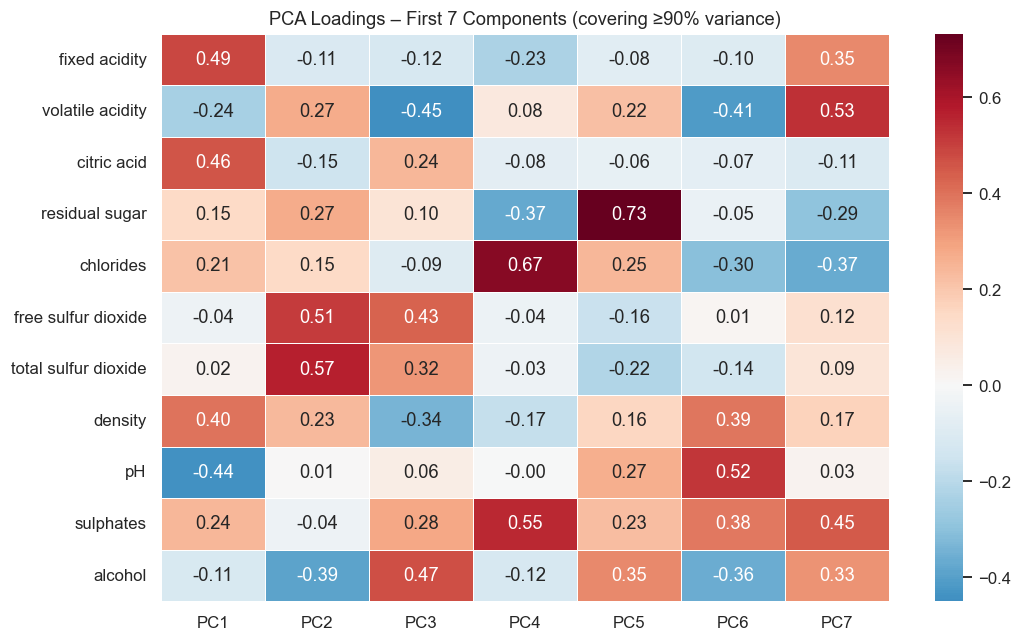

In [14]:
pca_full_fit = PCA()
pca_full_fit.fit(X_scaled)

loadings = pd.DataFrame(
    pca_full_fit.components_[:n_components_90].T,
    index=feature_cols,
    columns=[f'PC{i}' for i in range(1, n_components_90 + 1)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title(f'PCA Loadings – First {n_components_90} Components (covering ≥90% variance)')
plt.tight_layout()
plt.show()

The heatmap above shows how each original feature contributes to each principal component. Strong positive or negative loadings (dark colours) indicate that a feature plays a major role in that component. Features that share similarly large loadings on the same component are correlated/redundant with each other.